<a href="https://colab.research.google.com/github/RafaXzaviero/PengolahanCitraDigital/blob/main/1DeepLabV3%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 🌊 PROYEK PENGOLAHAN CITRA DIGITAL — SEGMENTASI CITRA
# Model: DeepLabv3+ (Model lanjutan)
# Evaluasi: IoU, Dice, Pixel Accuracy
# ============================================================

# 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2️⃣ Import Library Dasar
import os, glob, cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("✅ Semua library telah dimuat dengan sukses.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Semua library telah dimuat dengan sukses.


Jumlah gambar ditemukan: 290
Jumlah mask ditemukan  : 290

📥 Membaca semua gambar & mask...


100%|██████████| 290/290 [01:26<00:00,  3.34it/s]



✅ Dataset selesai dimuat!
Bentuk gambar: (290, 256, 256, 3)
Bentuk mask  : (290, 256, 256, 1)

📊 Data terbagi:
Train : 202 sampel
Val   : 44 sampel
Test  : 44 sampel


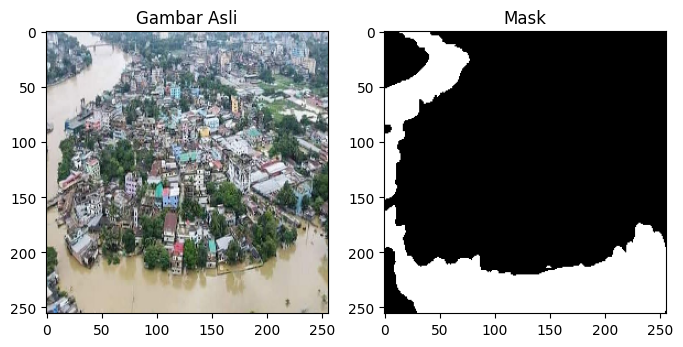

In [ ]:
# ============================================================
# 📦 PENGAMBILAN DATASET DARI GOOGLE DRIVE
# ============================================================

path_gambar = "/content/drive/MyDrive/Colab Notebooks/dataset/Image/"
path_mask   = "/content/drive/MyDrive/Colab Notebooks/dataset/Mask/"

gambar_paths = sorted(glob.glob(os.path.join(path_gambar, "*.jpg"))) + sorted(glob.glob(os.path.join(path_gambar, "*.png")))
mask_paths   = sorted(glob.glob(os.path.join(path_mask, "*.jpg")))   + sorted(glob.glob(os.path.join(path_mask, "*.png")))

print(f"Jumlah gambar ditemukan: {len(gambar_paths)}")
print(f"Jumlah mask ditemukan  : {len(mask_paths)}")

assert len(gambar_paths) == len(mask_paths), "❌ Jumlah gambar dan mask tidak sama!"

# Fungsi bantu
IMG_SIZE = 256

def baca_gambar(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img = img.astype(np.float32) / 255.0
    return img

def baca_mask(path, size=IMG_SIZE):
    msk = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    msk = cv2.resize(msk, (size, size))
    msk = (msk > 127).astype(np.float32)
    msk = np.expand_dims(msk, axis=-1)
    return msk

print("\n📥 Membaca semua gambar & mask...")
gambar = np.array([baca_gambar(p) for p in tqdm(gambar_paths)], dtype=np.float32)
mask   = np.array([baca_mask(p) for p in tqdm(mask_paths)], dtype=np.float32)

print("\n✅ Dataset selesai dimuat!")
print("Bentuk gambar:", gambar.shape)
print("Bentuk mask  :", mask.shape)

# Split data
x_temp, x_test, y_temp, y_test = train_test_split(gambar, mask, test_size=0.15, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.1765, random_state=42)

print(f"\n📊 Data terbagi:")
print(f"Train : {len(x_train)} sampel")
print(f"Val   : {len(x_val)} sampel")
print(f"Test  : {len(x_test)} sampel")

# Cek contoh data
idx = np.random.randint(0, len(x_train))
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(x_train[idx]); plt.title("Gambar Asli")
plt.subplot(1,2,2); plt.imshow(y_train[idx].squeeze(), cmap='gray'); plt.title("Mask")
plt.show()

In [ ]:
# ============================================================
# 🧠 MODEL DEEPLABV3+ (Model Lanjutan)
# ============================================================
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D, BatchNormalization, Activation, Concatenate, GlobalAveragePooling2D, Reshape, Multiply

def ASPP(x, filters):
    shape = x.shape
    y1 = Conv2D(filters, 1, padding='same', activation='relu')(x)
    y2 = Conv2D(filters, 3, dilation_rate=6, padding='same', activation='relu')(x)
    y3 = Conv2D(filters, 3, dilation_rate=12, padding='same', activation='relu')(x)
    y4 = Conv2D(filters, 3, dilation_rate=18, padding='same', activation='relu')(x)
    y5 = GlobalAveragePooling2D()(x)
    y5 = Reshape((1, 1, shape[-1]))(y5)
    y5 = Conv2D(filters, 1, padding='same', activation='relu')(y5)
    y5 = UpSampling2D(size=(shape[1], shape[2]), interpolation='bilinear')(y5)
    y = Concatenate()([y1, y2, y3, y4, y5])
    y = Conv2D(filters, 1, padding='same', activation='relu')(y)
    return y

def DeepLabV3Plus(input_shape=(256, 256, 3)):
    inputs = Input(shape=input_shape)
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)

    image_features = base_model.get_layer('conv4_block6_out').output
    x_a = ASPP(image_features, 256)
    x_a = UpSampling2D(size=(4, 4), interpolation='bilinear')(x_a)

    low_level = base_model.get_layer('conv2_block3_out').output
    low_level = Conv2D(48, 1, padding='same', activation='relu')(low_level)

    x = Concatenate()([x_a, low_level])
    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = UpSampling2D(size=(4, 4), interpolation='bilinear')(x)

    outputs = Conv2D(1, 1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)
    return model

model = DeepLabV3Plus()
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 17,823,921 (67.99 MB)

 Trainable params: 17,793,329 (67.88 MB)

 Non-trainable params: 30,592 (119.50 KB)

In [ ]:
# ============================================================
# ⚙️ METRIK DAN CALLBACK
# ============================================================
@tf.keras.utils.register_keras_serializable()
def iou_metric(y_true, y_pred, smooth=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

@tf.keras.utils.register_keras_serializable()
def dice_coefficient(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

@tf.keras.utils.register_keras_serializable()
def pixel_accuracy(y_true, y_pred):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    y_true_bin = tf.cast(y_true, tf.float32)
    correct = tf.reduce_sum(tf.cast(tf.equal(y_true_bin, y_pred_bin), tf.float32))
    total = tf.cast(tf.size(y_true_bin), tf.float32)
    return correct / (total + 1e-7)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[iou_metric, dice_coefficient, pixel_accuracy]
)

model_saver = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/model_deeplabv3plus_best.h5",
    monitor='val_iou_metric',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("✅ Model DeepLabv3+ siap dilatih.")

✅ Model DeepLabv3+ siap dilatih.


In [ ]:
# ============================================================
# 🚀 TRAINING MODEL
# ============================================================
EPOCHS = 80
BATCH_SIZE = 8

riwayat = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[model_saver],
    verbose=1
)

Epoch 1/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.5407 - iou_metric: 0.4260 - loss: 0.5788 - pixel_accuracy: 0.7170   
Epoch 1: val_iou_metric improved from -inf to 0.43590, saving model to /content/drive/MyDrive/Colab Notebooks/model_deeplabv3plus_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - dice_coefficient: 0.5463 - iou_metric: 0.4311 - loss: 0.5746 - pixel_accuracy: 0.7196 - val_dice_coefficient: 0.6061 - val_iou_metric: 0.4359 - val_loss: 1.2876 - val_pixel_accuracy: 0.4716
Epoch 2/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - dice_coefficient: 0.8347 - iou_metric: 0.7184 - loss: 0.3257 - pixel_accuracy: 0.8677
Epoch 2: val_iou_metric did not improve from 0.43590
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 301ms/step - dice_coefficient: 0.8347 - iou_metric: 0.7184 - loss: 0.3250 - pixel_accuracy: 0.8681 - val_dice_coefficient: 0.6019 - val_iou_metric: 0.4316 - val_loss: 0.8179 - val_pixel_accuracy: 0.5195
Epoch 3/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - dice_coefficient: 0.8617 - iou_metric: 0.7581 - loss: 0.2570 - pixel_accuracy: 0.8953
Epoch 3: val_iou_metric improved from 0.43590 to 0.43594, saving model to /content/drive/MyDrive/Colab Notebooks/model_deeplabv3plus_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 412ms/step - dice_coefficient: 0.8620 - iou_metric: 0.7587 - loss: 0.2563 - pixel_accuracy: 0.8956 - val_dice_coefficient: 0.6061 - val_iou_metric: 0.4359 - val_loss: 1.3414 - val_pixel_accuracy: 0.4738
Epoch 4/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - dice_coefficient: 0.8992 - iou_metric: 0.8173 - loss: 0.1960 - pixel_accuracy: 0.9207
Epoch 4: val_iou_metric did not improve from 0.43594
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 301ms/step - dice_coefficient: 0.8991 - iou_metric: 0.8172 - loss: 0.1961 - pixel_accuracy: 0.9207 - val_dice_coefficient: 0.6060 - val_iou_metric: 0.4359 - val_loss: 2.4630 - val_pixel_accuracy: 0.4359
Epoch 5/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - dice_coefficient: 0.9054 - iou_metric: 0.8278 - loss: 0.1780 - pixel_accuracy: 0.9285
Epoch 5: val_iou_metric did not improve from 0.43594
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - dice_coefficient: 0.9053 - iou_metric: 0.8277 - loss: 0.1780 - pixel_accuracy: 0.9283 - val_dice_coeffic

26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 373ms/step - dice_coefficient: 0.9089 - iou_metric: 0.8334 - loss: 0.1804 - pixel_accuracy: 0.9264 - val_dice_coefficient: 0.6063 - val_iou_metric: 0.4362 - val_loss: 2.7712 - val_pixel_accuracy: 0.4368
Epoch 7/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - dice_coefficient: 0.9197 - iou_metric: 0.8520 - loss: 0.1604 - pixel_accuracy: 0.9333
Epoch 7: val_iou_metric improved from 0.43621 to 0.43671, saving model to /content/drive/MyDrive/Colab Notebooks/model_deeplabv3plus_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 354ms/step - dice_coefficient: 0.9196 - iou_metric: 0.8518 - loss: 0.1603 - pixel_accuracy: 0.9333 - val_dice_coefficient: 0.6068 - val_iou_metric: 0.4367 - val_loss: 3.0567 - val_pixel_accuracy: 0.4385
Epoch 8/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - dice_coefficient: 0.9285 - iou_metric: 0.8670 - loss: 0.1404 - pixel_accuracy: 0.9418
Epoch 8: val_iou_metric did not improve from 0.43671
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step - dice_coefficient: 0.9283 - iou_metric: 0.8668 - loss: 0.1406 - pixel_accuracy: 0.9417 - val_dice_coefficient: 0.6060 - val_iou_metric: 0.4359 - val_loss: 4.5112 - val_pixel_accuracy: 0.4359
Epoch 9/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - dice_coefficient: 0.9277 - iou_metric: 0.8654 - loss: 0.1423 - pixel_accuracy: 0.9404
Epoch 9: val_iou_metric improved from 0.43671 to 0.44250, saving model to /content/drive/MyDrive/Colab Notebooks/model_deeplabv3plus_best.h5


...

26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 362ms/step - dice_coefficient: 0.9656 - iou_metric: 0.9336 - loss: 0.0646 - pixel_accuracy: 0.9723 - val_dice_coefficient: 0.8904 - val_iou_metric: 0.8047 - val_loss: 0.3209 - val_pixel_accuracy: 0.9036
Epoch 50/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - dice_coefficient: 0.9652 - iou_metric: 0.9329 - loss: 0.0651 - pixel_accuracy: 0.9722
Epoch 50: val_iou_metric improved from 0.80470 to 0.80619, saving model to /content/drive/MyDrive/Colab Notebooks/model_deeplabv3plus_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 363ms/step - dice_coefficient: 0.9652 - iou_metric: 0.9328 - loss: 0.0651 - pixel_accuracy: 0.9722 - val_dice_coefficient: 0.8917 - val_iou_metric: 0.8062 - val_loss: 0.3235 - val_pixel_accuracy: 0.9069
Epoch 51/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - dice_coefficient: 0.9640 - iou_metric: 0.9306 - loss: 0.0640 - pixel_accuracy: 0.9726
Epoch 51: val_iou_metric did not improve from 0.80619
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 315ms/step - dice_coefficient: 0.9640 - iou_metric: 0.9306 - loss: 0.0640 - pixel_accuracy: 0.9726 - val_dice_coefficient: 0.8902 - val_iou_metric: 0.8040 - val_loss: 0.3424 - val_pixel_accuracy: 0.9053
Epoch 52/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - dice_coefficient: 0.9661 - iou_metric: 0.9345 - loss: 0.0604 - pixel_accuracy: 0.9744
Epoch 52: val_iou_metric did not improve from 0.80619
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step - dice_coefficient: 0.9661 - iou_metric: 0.9345 - loss: 0.0605 - pixel_accuracy: 0.9744 - val_dice_coef

26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 592ms/step - dice_coefficient: 0.9696 - iou_metric: 0.9412 - loss: 0.0551 - pixel_accuracy: 0.9764 - val_dice_coefficient: 0.8921 - val_iou_metric: 0.8068 - val_loss: 0.3747 - val_pixel_accuracy: 0.9074
Epoch 65/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - dice_coefficient: 0.9693 - iou_metric: 0.9405 - loss: 0.0543 - pixel_accuracy: 0.9766
Epoch 65: val_iou_metric did not improve from 0.80677
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - dice_coefficient: 0.9693 - iou_metric: 0.9406 - loss: 0.0543 - pixel_accuracy: 0.9766 - val_dice_coefficient: 0.8902 - val_iou_metric: 0.8036 - val_loss: 0.3936 - val_pixel_accuracy: 0.9062
Epoch 66/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - dice_coefficient: 0.9722 - iou_metric: 0.9460 - loss: 0.0522 - pixel_accuracy: 0.9777
Epoch 66: val_iou_metric did not improve from 0.80677
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 323ms/step - dice_coefficient: 0.9722 - iou_metric: 0.9460 - loss: 0.0521 - pixel_accuracy: 0.9777 - val_dice_coe

26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 565ms/step - dice_coefficient: 0.9712 - iou_metric: 0.9441 - loss: 0.0516 - pixel_accuracy: 0.9780 - val_dice_coefficient: 0.8926 - val_iou_metric: 0.8077 - val_loss: 0.3508 - val_pixel_accuracy: 0.9082
Epoch 78/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - dice_coefficient: 0.9734 - iou_metric: 0.9483 - loss: 0.0489 - pixel_accuracy: 0.9791
Epoch 78: val_iou_metric did not improve from 0.80766
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 313ms/step - dice_coefficient: 0.9733 - iou_metric: 0.9481 - loss: 0.0490 - pixel_accuracy: 0.9790 - val_dice_coefficient: 0.8917 - val_iou_metric: 0.8061 - val_loss: 0.3439 - val_pixel_accuracy: 0.9081
Epoch 79/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - dice_coefficient: 0.9720 - iou_metric: 0.9457 - loss: 0.0527 - pixel_accuracy: 0.9777
Epoch 79: val_iou_metric improved from 0.80766 to 0.80822, saving model to /content/drive/MyDrive/Colab Notebooks/model_deeplabv3plus_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 378ms/step - dice_coefficient: 0.9720 - iou_metric: 0.9456 - loss: 0.0528 - pixel_accuracy: 0.9776 - val_dice_coefficient: 0.8928 - val_iou_metric: 0.8082 - val_loss: 0.3427 - val_pixel_accuracy: 0.9082
Epoch 80/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - dice_coefficient: 0.9701 - iou_metric: 0.9421 - loss: 0.0535 - pixel_accuracy: 0.9771
Epoch 80: val_iou_metric did not improve from 0.80822
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 318ms/step - dice_coefficient: 0.9701 - iou_metric: 0.9421 - loss: 0.0535 - pixel_accuracy: 0.9771 - val_dice_coefficient: 0.8918 - val_iou_metric: 0.8063 - val_loss: 0.3591 - val_pixel_accuracy: 0.9079


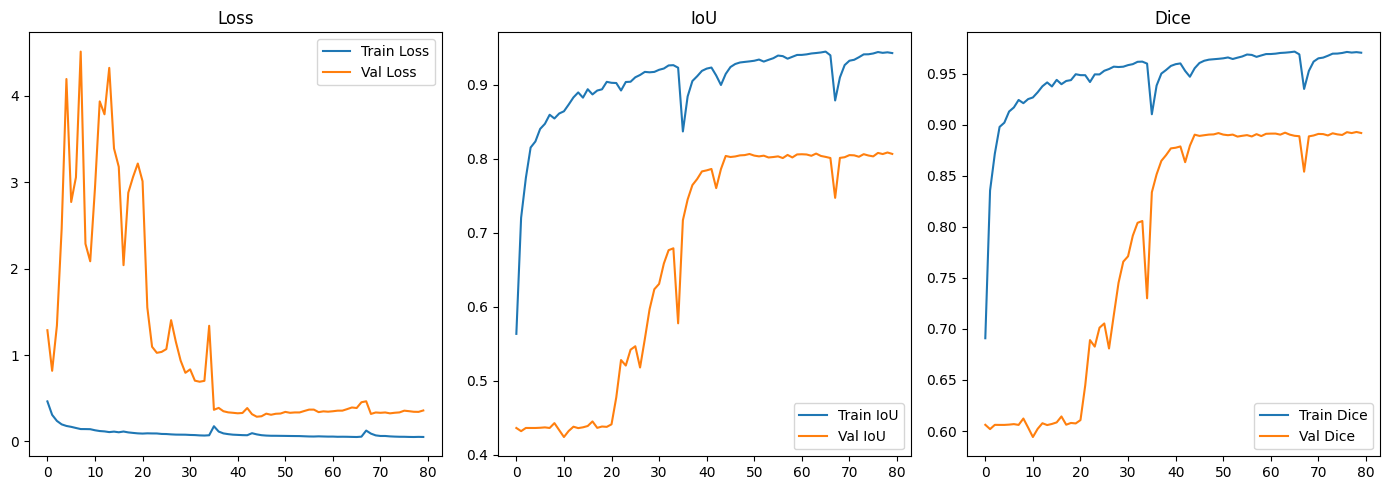

In [ ]:

# ============================================================
# 📈 VISUALISASI HASIL TRAINING
# ============================================================
def plot_training(history):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['iou_metric'], label='Train IoU')
    plt.plot(history.history['val_iou_metric'], label='Val IoU')
    plt.title('IoU')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history['dice_coefficient'], label='Train Dice')
    plt.plot(history.history['val_dice_coefficient'], label='Val Dice')
    plt.title('Dice')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training(riwayat)

In [ ]:
# ============================================================
# 📊 EVALUASI MODEL DAN PREDIKSI
# ============================================================
print("\n📊 Evaluasi pada data test:")
hasil_test = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE, verbose=1)
for nama, nilai in zip(model.metrics_names, hasil_test):
    print(f"{nama:<25}: {nilai:.4f}")


📊 Evaluasi pada data test:
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - dice_coefficient: 0.8987 - iou_metric: 0.8173 - loss: 0.2917 - pixel_accuracy: 0.9195
loss                     : 0.2926
compile_metrics          : 0.8169


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


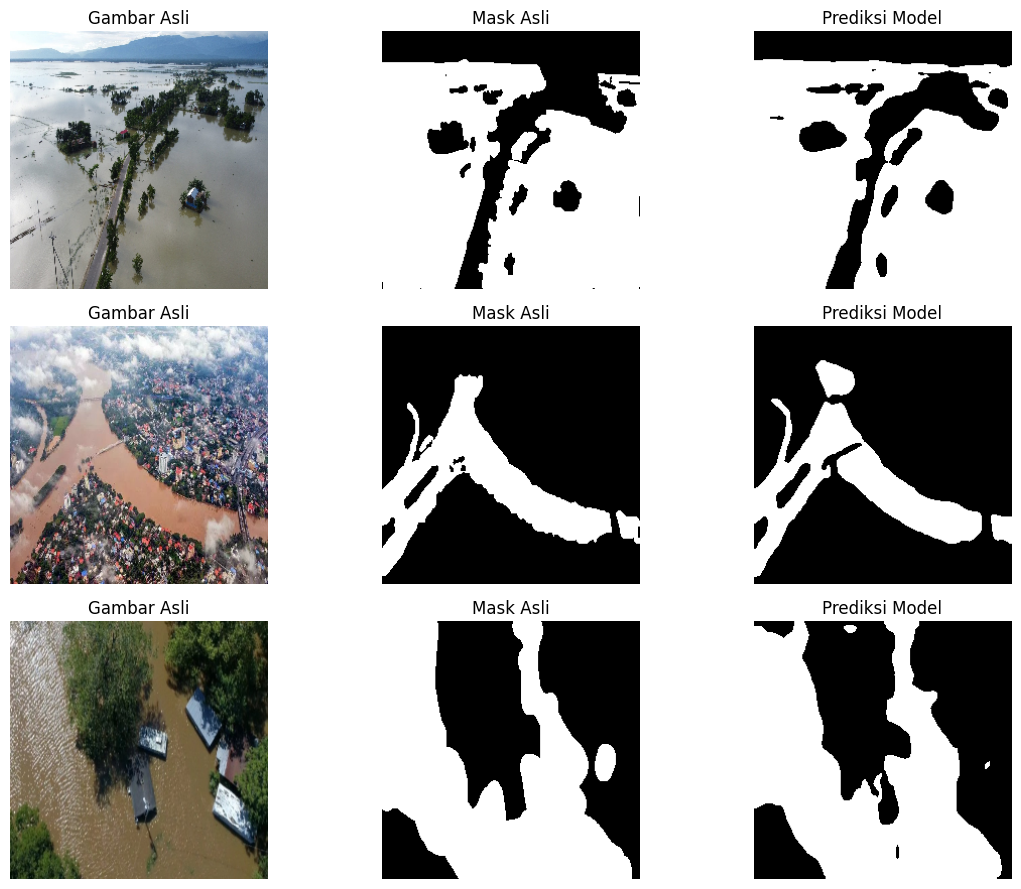

In [ ]:
# ============================================================
# 🖼️ VISUALISASI PREDIKSI
# ============================================================
def tampilkan_prediksi(model, x_data, y_true, n=5):
    plt.figure(figsize=(12, n * 3))
    for i in range(n):
        idx = np.random.randint(0, len(x_data))
        gambar = x_data[idx]
        mask_asli = y_true[idx].squeeze()
        pred = model.predict(np.expand_dims(gambar, 0))[0].squeeze()
        pred_bin = (pred > 0.5).astype(np.float32)

        plt.subplot(n, 3, 3*i+1)
        plt.imshow(gambar)
        plt.title("Gambar Asli"); plt.axis("off")

        plt.subplot(n, 3, 3*i+2)
        plt.imshow(mask_asli, cmap='gray')
        plt.title("Mask Asli"); plt.axis("off")

        plt.subplot(n, 3, 3*i+3)
        plt.imshow(pred_bin, cmap='gray')
        plt.title("Prediksi Model"); plt.axis("off")
    plt.tight_layout(); plt.show()

tampilkan_prediksi(model, x_test, y_test, n=3)